# Fundamental Analysis 1: Triple-Barrier Labels And True Drift

## Main result

Under the current DGP, triple-barrier label `1` contains some information about true positive drift, but it is noisy. The relationship becomes more useful when drift is high, target portfolio volatility is low, and the horizon is longer.

Note that the notebook should be read together with `fundamental0.ipynb. The volatility axis below is **target portfolio annual volatility**, while the triple-barrier itself uses **stock-level rolling volatility**. More on this can be found in fundamental0.ipynb.

## Clarification

What is given in this notebook is not the final use of triple-barrier labeling in the meta-labeling pipeline. In the full workflow, the primary strategy first creates long/short trade candidates, and the triple barrier labels whether those trade directions hit the profit-taking barrier.


Here, we remove the primary strategy and use long-only candidates to test a different question: when, if ever, does triple-barrier label `1` help identify stocks that have positive drift?

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "fundamental_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "fundamental_analysis":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fundamental_analysis.fundamental_helpers.helper1 import (
    run_fundamental1_single,
    run_fundamental1_grid,
    plot_metric_heatmaps,
    plot_stacked_horizon_3d,
    save_table,
)

TABLE_DIR = PROJECT_ROOT / "fundamental_analysis" / "fundamental_tables"
FIGURE_DIR = PROJECT_ROOT / "fundamental_analysis" / "fundamental_figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
plt.style.use("default")

## DGP Configuration

The DGP notation follows the original setup, with a functionised form for simulation setting. The only simplification here is that up stocks receive a fixed positive drift and all other stocks have zero drift, for the fact that we want to check a grid of values.

In [2]:
N = 500
T = 10_000
K = 10
split = (0.6, 0.4)
component_seed = 0

n_up = 100
vol_window = 20
barrier_multiplier = 1.0

full_target_portfolio_annual_vol_grid = np.arange(0.02, 0.22, 0.02)
full_annual_drift_grid = np.arange(0.10, 1.00, 0.10)
full_horizons = [30, 60, 90, 150]
full_n_sims = 20

RUN_FULL_GRID = False

if RUN_FULL_GRID:
    target_portfolio_annual_vol_grid = full_target_portfolio_annual_vol_grid
    annual_drift_grid = full_annual_drift_grid
    horizons = full_horizons
    n_sims = full_n_sims
    event_stride = 20
else:
    target_portfolio_annual_vol_grid = np.array([0.02, 0.06, 0.10, 0.14, 0.18, 0.20])
    annual_drift_grid = np.array([0.10, 0.30, 0.50, 0.70, 0.90])
    horizons = [30, 60, 90, 150]
    n_sims = 3
    event_stride = 40

base_seed = 20_000

{
    "target_portfolio_annual_vol_grid": target_portfolio_annual_vol_grid.tolist(),
    "annual_drift_grid": annual_drift_grid.tolist(),
    "horizons": horizons,
    "n_sims": n_sims,
    "event_stride": event_stride,
}

{'target_portfolio_annual_vol_grid': [0.02, 0.06, 0.1, 0.14, 0.18, 0.2],
 'annual_drift_grid': [0.1, 0.3, 0.5, 0.7, 0.9],
 'horizons': [30, 60, 90, 150],
 'n_sims': 3,
 'event_stride': 40}

## Single Scenario

Example scenario, that is intentionally simple. It gives a first read on how often true drift stocks receive label `1`, and how often zero-drift stocks also receive label `1`.

In [3]:
single = run_fundamental1_single(
    seed=base_seed,
    target_portfolio_annual_vol=0.10,
    annual_drift=0.30,
    horizon=60,
    N=N,
    T=T,
    K=K,
    n_up=n_up,
    split=split,
    component_seed=component_seed,
    vol_window=vol_window,
    barrier_multiplier=barrier_multiplier,
    event_stride=event_stride,
)

single_events = single["events"]
single_metrics = pd.DataFrame([single["metrics"]])
single_metrics

,n_events,tp,fn,fp,tn,true_positive_rate,false_negative_rate,false_positive_rate,true_negative_rate,precision,label_positive_rate,true_drift_event_rate,balanced_accuracy,pt_hit_share,sl_hit_share,vertical_hit_share,avg_time_to_pt,avg_time_to_sl
0,124000,8383,16417,29945,69255,0.338024,0.661976,0.301865,0.698135,0.218717,0.309097,0.2,0.51808,0.309097,0.163403,0.5275,27.834247,36.73966


In [4]:
pd.crosstab(
    single_events["true_drift_label"],
    single_events["label"],
    rownames=["true drift stock"],
    colnames=["triple-barrier label"],
    normalize="index",
)

triple-barrier label,0,1
true drift stock,,
0,0.698135,0.301865
1,0.661976,0.338024


In [5]:
(
    single_events
    .groupby("true_drift_label")
    .agg(
        n_events=("label", "size"),
        label_positive_rate=("label", "mean"),
        pt_hit_share=("hit_type", lambda x: (x == "pt").mean()),
        sl_hit_share=("hit_type", lambda x: (x == "sl").mean()),
        vertical_share=("hit_type", lambda x: (x == "vertical").mean()),
    )
)

,n_events,label_positive_rate,pt_hit_share,sl_hit_share,vertical_share
true_drift_label,,,,,
0,99200,0.301865,0.301865,0.166079,0.532056
1,24800,0.338024,0.338024,0.152702,0.509274


## Grid Simulation

The grid changes target portfolio volatility, annual drift, and horizon. The output is averaged across simulation seeds.

In [6]:
grid_results, grid_summary = run_fundamental1_grid(
    target_portfolio_annual_vol_grid=target_portfolio_annual_vol_grid,
    annual_drift_grid=annual_drift_grid,
    horizons=horizons,
    n_sims=n_sims,
    base_seed=base_seed,
    N=N,
    T=T,
    K=K,
    n_up=n_up,
    split=split,
    component_seed=component_seed,
    vol_window=vol_window,
    barrier_multiplier=barrier_multiplier,
    event_stride=event_stride,
    progress=True,
)

save_table(grid_results, TABLE_DIR / "fundamental1_grid_results.csv")
save_table(grid_summary, TABLE_DIR / "fundamental1_grid_summary.csv")

grid_summary.head()

completed 36/360
completed 72/360
completed 108/360
completed 144/360
completed 180/360
completed 216/360
completed 252/360
completed 288/360
completed 324/360
completed 360/360


,horizon,target_portfolio_annual_vol,annual_drift,n_events,tp,fn,fp,tn,true_positive_rate,false_negative_rate,false_positive_rate,true_negative_rate,precision,label_positive_rate,true_drift_event_rate,balanced_accuracy,pt_hit_share,sl_hit_share,vertical_hit_share,avg_time_to_pt,avg_time_to_sl
0,30,0.02,0.1,124500.0,8198.333333,16701.666667,28280.0,71320.0,0.329250,0.670750,0.283936,0.716064,0.224744,0.292999,0.2,0.522657,0.292999,0.264150,0.442851,16.126977,16.721045
1,30,0.02,0.3,124500.0,10793.000000,14107.000000,28280.0,71320.0,0.433454,0.566546,0.283936,0.716064,0.276229,0.313839,0.2,0.574759,0.313839,0.250300,0.435861,16.105036,16.697715
2,30,0.02,0.5,124500.0,13415.666667,11484.333333,28280.0,71320.0,0.538782,0.461218,0.283936,0.716064,0.321743,0.334905,0.2,0.627423,0.334905,0.240466,0.424629,15.987526,16.690057
3,30,0.02,0.7,124500.0,15787.666667,9112.333333,28280.0,71320.0,0.634043,0.365957,0.283936,0.716064,0.358248,0.353957,0.2,0.675054,0.353957,0.233588,0.412455,15.777296,16.684773
4,30,0.02,0.9,124500.0,17789.666667,7110.333333,28280.0,71320.0,0.714444,0.285556,0.283936,0.716064,0.386134,0.370037,0.2,0.715254,0.370037,0.228734,0.401229,15.496121,16.686025


## Main Tables

In [7]:
horizon_summary = (
    grid_results
    .groupby("horizon")[[
        "true_positive_rate",
        "false_positive_rate",
        "precision",
        "balanced_accuracy",
        "label_positive_rate",
        "pt_hit_share",
        "sl_hit_share",
        "vertical_hit_share",
    ]]
    .mean()
)

horizon_summary

,true_positive_rate,false_positive_rate,precision,balanced_accuracy,label_positive_rate,pt_hit_share,sl_hit_share,vertical_hit_share
horizon,,,,,,,,
30,0.362768,0.288164,0.236606,0.537302,0.303085,0.303085,0.176244,0.520671
60,0.399499,0.296822,0.247115,0.551338,0.317357,0.317357,0.134346,0.548296
90,0.420872,0.297236,0.255352,0.561818,0.321963,0.321963,0.111660,0.566377
150,0.443808,0.293207,0.266147,0.575301,0.323327,0.323327,0.086267,0.590406


In [8]:
main_cols = [
    "horizon",
    "target_portfolio_annual_vol",
    "annual_drift",
    "true_positive_rate",
    "false_positive_rate",
    "precision",
    "balanced_accuracy",
    "label_positive_rate",
]

grid_summary.sort_values("balanced_accuracy", ascending=False)[main_cols].head(10)

,horizon,target_portfolio_annual_vol,annual_drift,true_positive_rate,false_positive_rate,precision,balanced_accuracy,label_positive_rate
94,150,0.02,0.9,0.955379,0.314668,0.431514,0.820356,0.442810
64,90,0.02,0.9,0.899194,0.306240,0.423316,0.796477,0.424831
93,150,0.02,0.7,0.903442,0.314668,0.417857,0.794387,0.432423
34,60,0.02,0.9,0.839435,0.299005,0.412402,0.770215,0.407091
63,90,0.02,0.7,0.827124,0.306240,0.403060,0.760442,0.410417
92,150,0.02,0.5,0.806206,0.314668,0.390443,0.745769,0.412976
33,60,0.02,0.7,0.757648,0.299005,0.387803,0.729321,0.390734
4,30,0.02,0.9,0.714444,0.283936,0.386134,0.715254,0.370037
62,90,0.02,0.5,0.718454,0.306240,0.369685,0.706107,0.388683
3,30,0.02,0.7,0.634043,0.283936,0.358248,0.675054,0.353957


In [9]:
grid_summary.sort_values("balanced_accuracy", ascending=True)[main_cols].head(10)

,horizon,target_portfolio_annual_vol,annual_drift,true_positive_rate,false_positive_rate,precision,balanced_accuracy,label_positive_rate
25,30,0.20,0.1,0.287938,0.285003,0.201640,0.501468,0.285590
20,30,0.18,0.1,0.290308,0.287272,0.201684,0.501518,0.287880
15,30,0.14,0.1,0.294739,0.290783,0.202168,0.501978,0.291574
55,60,0.20,0.1,0.289476,0.284177,0.202976,0.502650,0.285237
50,60,0.18,0.1,0.295013,0.289493,0.203042,0.502760,0.290597
10,30,0.10,0.1,0.298635,0.291965,0.203635,0.503335,0.293299
45,60,0.14,0.1,0.305914,0.298414,0.204001,0.503750,0.299914
85,90,0.20,0.1,0.285470,0.276156,0.205364,0.504657,0.278019
80,90,0.18,0.1,0.293710,0.283918,0.205482,0.504896,0.285876
75,90,0.14,0.1,0.308441,0.297154,0.206026,0.505643,0.299411


## Heatmaps

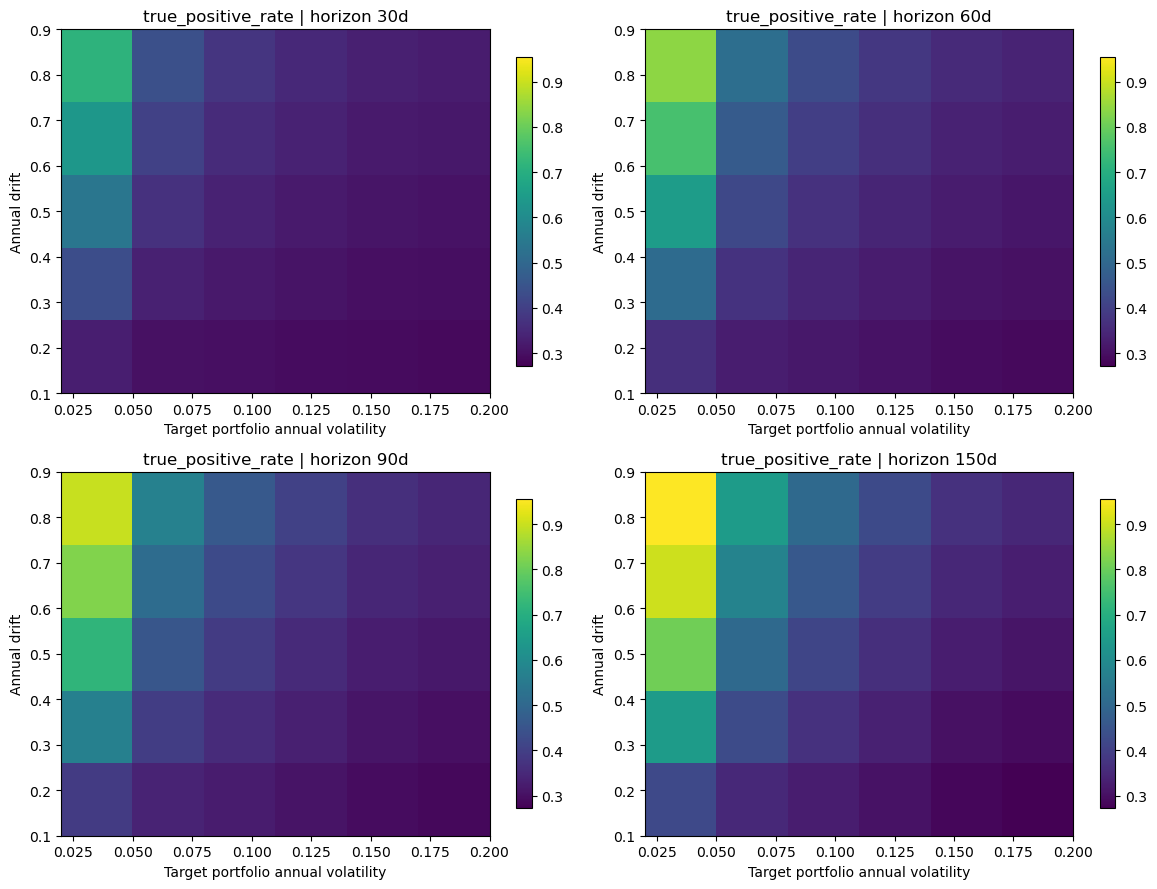

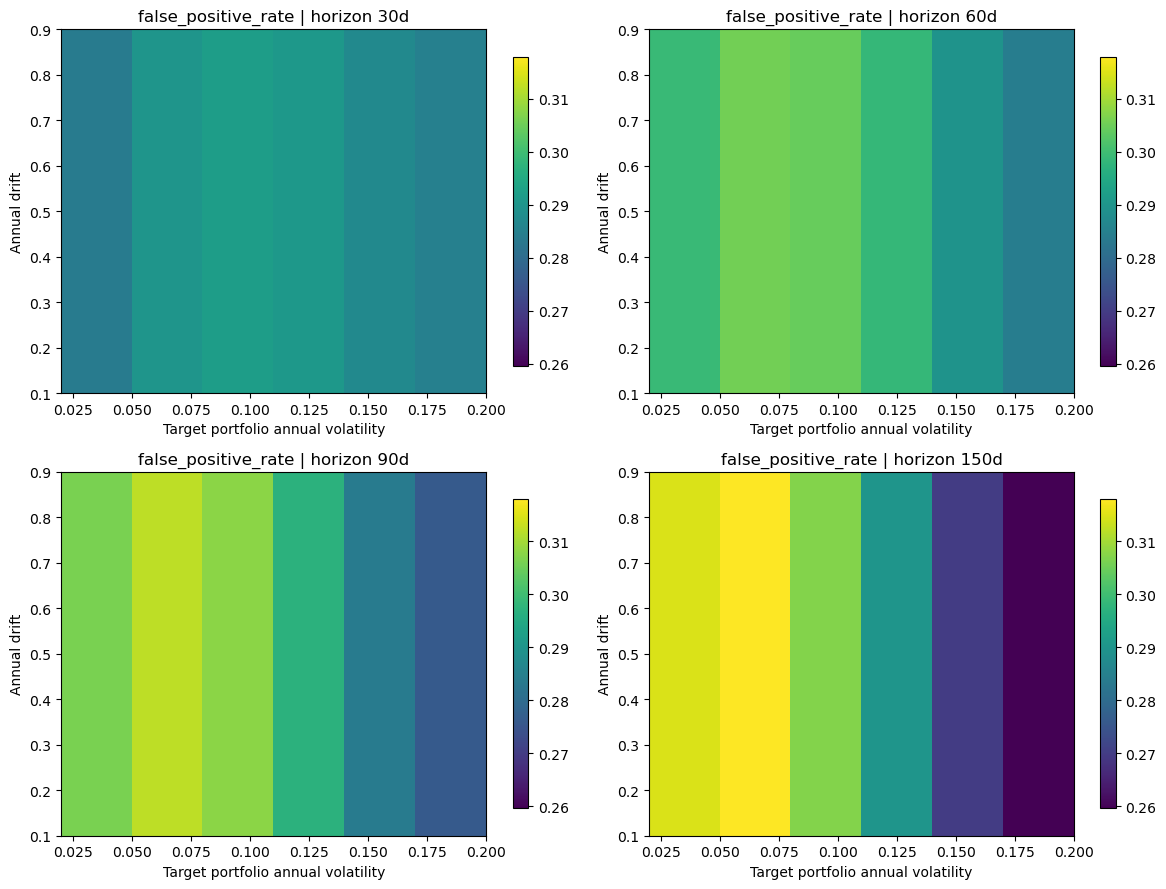

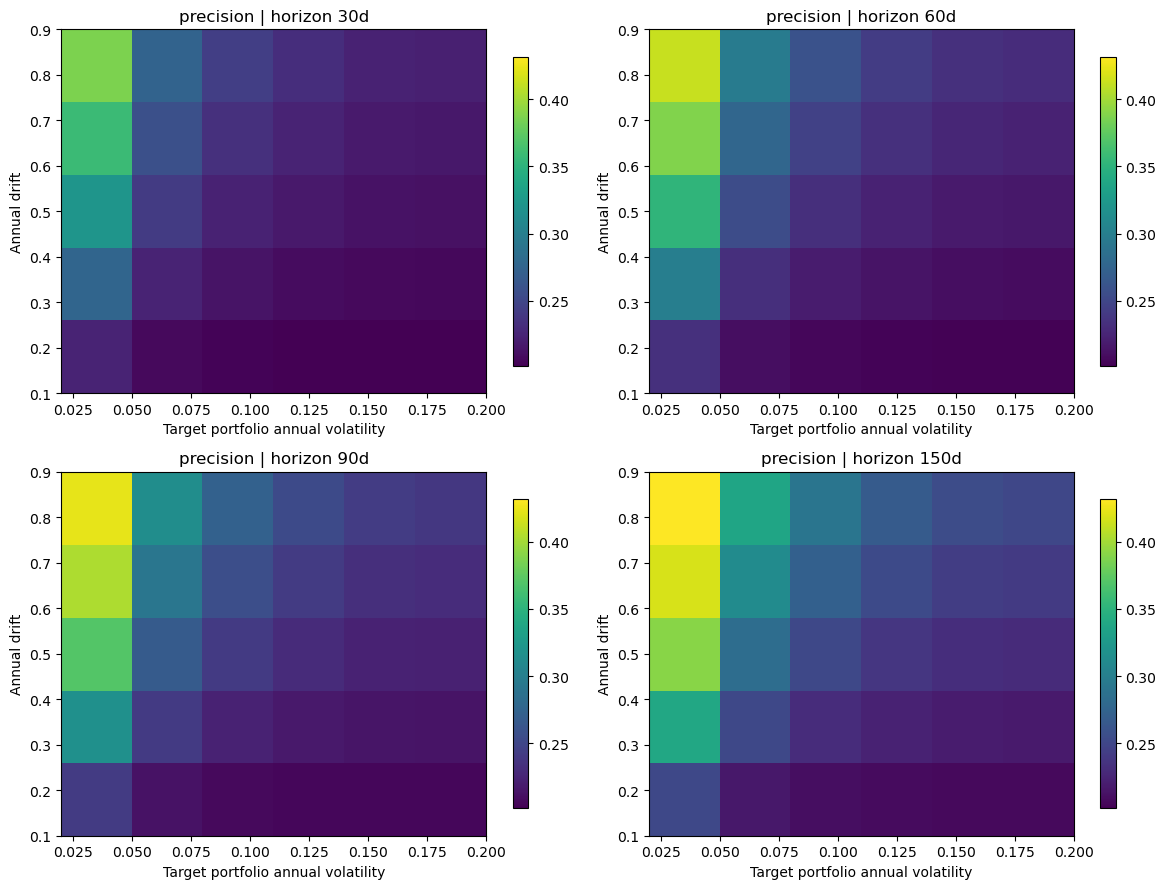

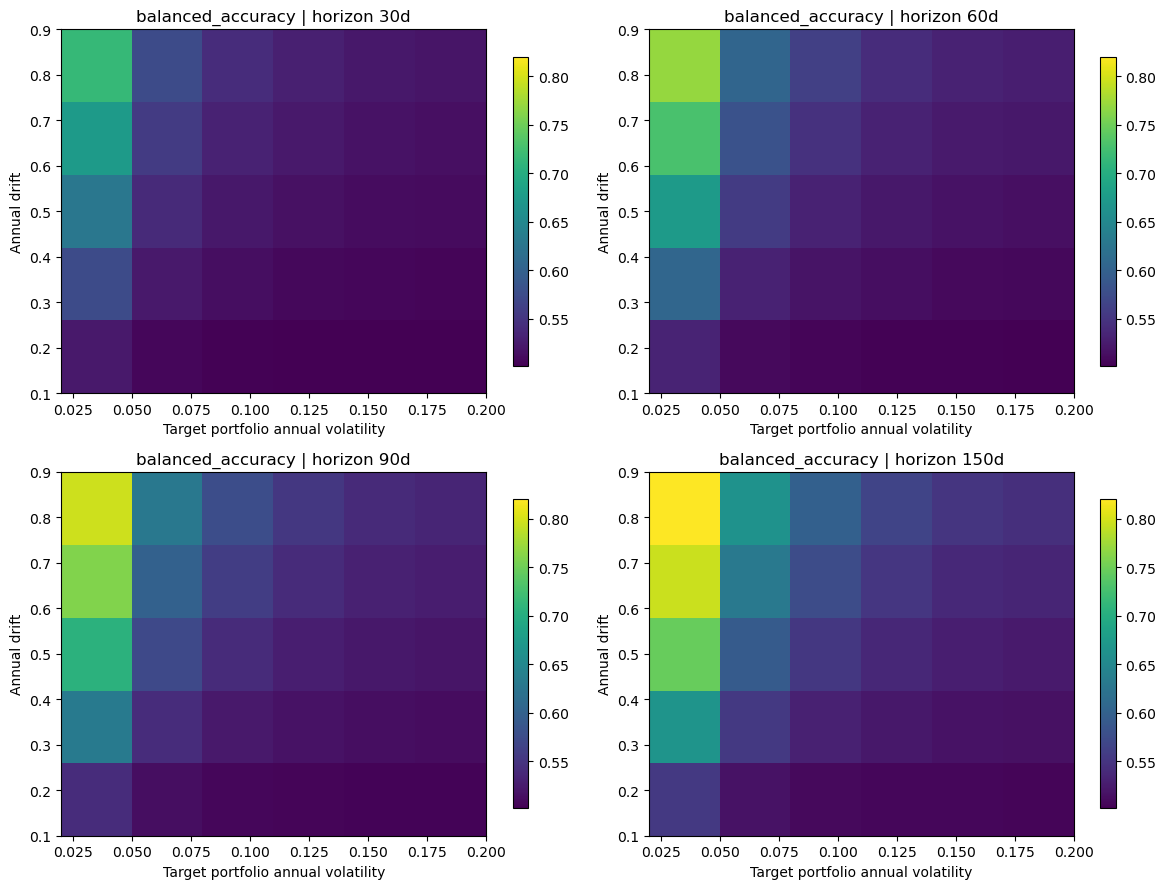

In [10]:
for metric in ["true_positive_rate", "false_positive_rate", "precision", "balanced_accuracy"]:
    fig, axes = plot_metric_heatmaps(
        grid_summary,
        metric=metric,
        horizons=horizons,
        cmap="viridis",
    )
    fig.savefig(FIGURE_DIR / f"fundamental1_heatmap_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 3D Horizon Views

Horizon is discrete here. These plots should be read as stacked horizon layers, not as a smooth continuous surface.

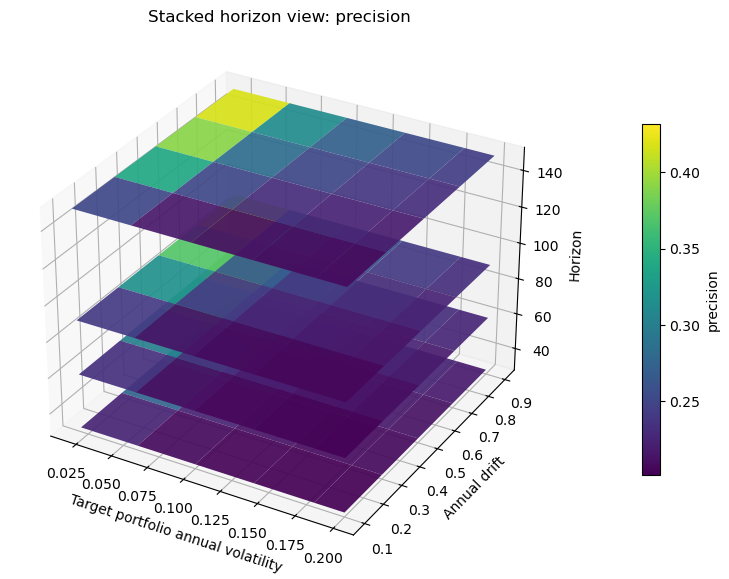

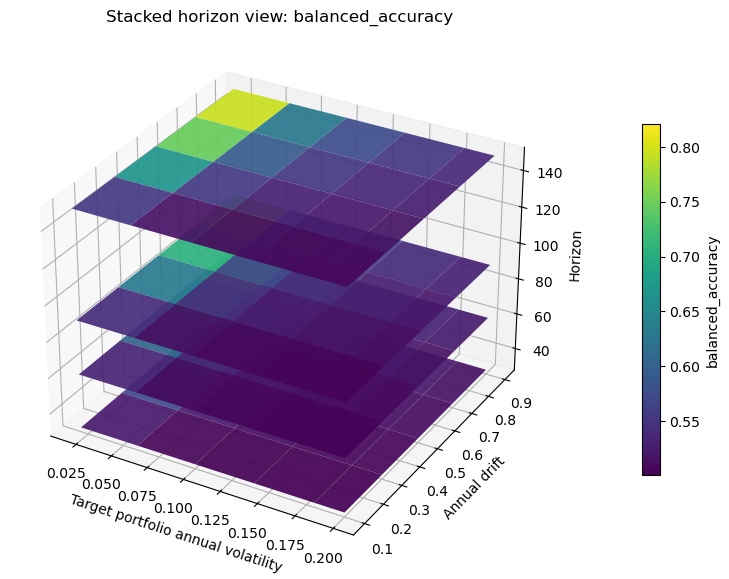

In [11]:
for metric in ["precision", "balanced_accuracy"]:
    fig, ax = plot_stacked_horizon_3d(
        grid_summary,
        metric=metric,
        horizons=horizons,
        cmap="viridis",
    )
    fig.savefig(FIGURE_DIR / f"fundamental1_3d_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()

## Short Interpretation

- Higher drift makes label `1` more informative about true drift.
- Longer horizons help because drift has more time to accumulate.
- Higher target portfolio volatility weakens the relationship, especially because stock-level volatility is much larger than the portfolio target.
- False positives remain important: zero-drift stocks can hit the profit-taking barrier by chance.
- The next step is to decide whether to change the DGP calibration, the triple-barrier construction, or both.